### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 

In [ ]:
import sympy as sy
import numpy as np
import scipy.linalg as scipy_linalg
import qutip as qt
from itertools import product
from tqdm import tqdm

# ------------------------------------------------------------------
# 1. Äußerer Code: Symbolische Vorberechnung (Einmalige Ausführung)
# ------------------------------------------------------------------
def prepare_floquet_functions(
    pulse_shape_builder,
    p_names,
    s,
    rH,
    rW,
    include_geometric=True,
    include_micromotion=True,
    include_g_correction=True,
    verbose=True
):
    """Berechnet Heff, W und M_sym symbolisch und erzeugt schnell auswertbare NumPy-Lambdas."""
    t_sym = sy.Symbol("t", real=True)
    p_syms = [sy.Symbol(name, real=True) for name in p_names]
    
    if verbose: print("1/2 Erstelle symbolischen Puls & berechne W und Heff ...")
    A_expr, wd_expr = pulse_shape_builder(t_sym, p_syms)
    
    orig_np_exp = np.exp
    np.exp = sy.exp
    try:
        W = W_Floquet_elements_fast(
            rW, wd_expr, s.resonances, s.E_array, s.V1_dressed_array, A=A_expr, V0=None, analytics=True
        )
        Heff = Heff_Floquet_total_matrix_summed(
            rH, wd_expr, A_expr, s.resonances, s.E_array, s.V1_dressed_array, V0=None, ref_state=None,
            dwd=wd_expr.diff(t_sym), dA=A_expr.diff(t_sym), t=t_sym, analytics=True, rW=rW,
            include_geometric=include_geometric, include_micromotion=include_micromotion,
            include_g_correction=include_g_correction, W=W
        )
    finally:
        np.exp = orig_np_exp
    
    resonances = dict(s.resonances) if isinstance(s.resonances, list) else s.resonances
    D, d_res = len(s.E_array), len(resonances)
    kref = min(resonances)

    M_sym = sy.zeros(D, d_res)
    for r in range(0, rW + 1):
        for l in range(D):
            for idx_a, a in enumerate(resonances):
                W_la = W[r, l, a]
                for p, (W_lp_a, _, _) in W_la.items():
                    phase = sy.exp(-sy.I * (s.E_array[kref] + p * wd_expr) * t_sym)
                    M_sym[l, idx_a] += phase * W_lp_a

    if verbose: print("2/2 Erzeuge Lambdified H_func und M_func ...")
    args_list = [t_sym] + p_syms
    H_func = sy.lambdify(args_list, sy.Matrix(Heff).doit(), modules=['numpy', 'scipy'])
    M_func = sy.lambdify(args_list, M_sym.doit(), modules=['numpy', 'scipy'])

    return H_func, M_func


# ------------------------------------------------------------------
# 2. Hilfsfunktionen: Vektorisierte H-Auswertung & Infidelity
# ------------------------------------------------------------------
def _eval_H_stack(H_func, t_mids, p_vals, d_res):
    try:
        H_all = np.asarray(H_func(t_mids, *p_vals), dtype=complex)
        if H_all.shape == (d_res, d_res, len(t_mids)):
            return H_all
    except Exception:
        pass
    H_all = np.empty((d_res, d_res, len(t_mids)), dtype=complex)
    for k, t_mid in enumerate(t_mids):
        H_all[:, :, k] = np.array(H_func(t_mid, *p_vals), dtype=complex).reshape(d_res, d_res)
    return H_all


def compute_pulse_infidelity(
    p_vals, H_func, M_func, t_mids, dt, tg, D, d_res, res_indices, ind_a, ind_b, state_a, state_b, target_metric, qobj_ideal=None
):
    H_all = _eval_H_stack(H_func, t_mids, p_vals, d_res)

    U_eff = np.eye(d_res, dtype=complex)
    for k in range(len(t_mids)):
        U_eff = scipy_linalg.expm(-1j * H_all[:, :, k] * dt) @ U_eff

    M_final = np.array(M_func(tg, *p_vals), dtype=complex).reshape(D, d_res)
    U_total = M_final @ U_eff

    if target_metric == "population":
        p_ab = np.abs(U_total[state_b, ind_a])**2
        p_ba = np.abs(U_total[state_a, ind_b])**2
        fidelity = 0.5 * (p_ab + p_ba)

    elif target_metric == "process":
        U_sub = U_total[res_indices, :]
        fidelity = qt.process_fidelity(qt.Qobj(U_sub), qobj_ideal)

    return 1.0 - fidelity


# ------------------------------------------------------------------
# 3. Entschlackte Parameter-Sweep Methode
# ------------------------------------------------------------------
# ------------------------------------------------------------------
# 1. Äußerer Code: Symbolische Vorberechnung (Einmalige Ausführung)
# ------------------------------------------------------------------
def prepare_floquet_functions(
    pulse_shape_builder, p_names, s, rH, rW,
    include_geometric=True, include_micromotion=True, include_g_correction=True, verbose=True
):
    """Berechnet Heff, W und M_sym symbolisch und erzeugt schnell auswertbare NumPy-Lambdas."""
    t_sym = sy.Symbol("t", real=True)
    p_syms = [sy.Symbol(name, real=True) for name in p_names]
    
    if verbose: print("1/2 Erstelle symbolischen Puls & berechne W und Heff ...")
    A_expr, wd_expr = pulse_shape_builder(t_sym, p_syms)
    
    orig_np_exp = np.exp
    np.exp = sy.exp
    try:
        W = W_Floquet_elements_fast(rW, wd_expr, s.resonances, s.E_array, s.V1_dressed_array, A=A_expr, V0=None, analytics=True)
        Heff = Heff_Floquet_total_matrix_summed(
            rH, wd_expr, A_expr, s.resonances, s.E_array, s.V1_dressed_array, V0=None, ref_state=None,
            dwd=wd_expr.diff(t_sym), dA=A_expr.diff(t_sym), t=t_sym, analytics=True, rW=rW,
            include_geometric=include_geometric, include_micromotion=include_micromotion,
            include_g_correction=include_g_correction, W=W
        )
    finally:
        np.exp = orig_np_exp
    
    resonances = dict(s.resonances) if isinstance(s.resonances, list) else s.resonances
    D, d_res, kref = len(s.E_array), len(resonances), min(resonances)

    M_sym = sy.zeros(D, d_res)
    for r in range(0, rW + 1):
        for l in range(D):
            for idx_a, a in enumerate(resonances):
                for p, (W_lp_a, _, _) in W[r, l, a].items():
                    M_sym[l, idx_a] += sy.exp(-sy.I * (s.E_array[kref] + p * wd_expr) * t_sym) * W_lp_a

    if verbose: print("2/2 Erzeuge Lambdified H_func und M_func ...")
    args_list = [t_sym] + p_syms
    return (
        sy.lambdify(args_list, sy.Matrix(Heff).doit(), modules=['numpy', 'scipy']),
        sy.lambdify(args_list, M_sym.doit(), modules=['numpy', 'scipy'])
    )


# ------------------------------------------------------------------
# 2. Hilfsfunktionen: Vektorisierte H-Auswertung & Infidelity
# ------------------------------------------------------------------
def _eval_H_stack(H_func, t_mids, p_vals, d_res):
    try:
        H_all = np.asarray(H_func(t_mids, *p_vals), dtype=complex)
        if H_all.shape == (d_res, d_res, len(t_mids)):
            return H_all
    except Exception:
        pass
    H_all = np.empty((d_res, d_res, len(t_mids)), dtype=complex)
    for k, t_mid in enumerate(t_mids):
        H_all[:, :, k] = np.array(H_func(t_mid, *p_vals), dtype=complex).reshape(d_res, d_res)
    return H_all


def compute_pulse_infidelity(
    p_vals, H_func, M_func, t_mids, dt, tg, D, d_res, res_indices, ind_a, ind_b, state_a, state_b, target_metric, qobj_ideal=None
):
    H_all = _eval_H_stack(H_func, t_mids, p_vals, d_res)

    U_eff = np.eye(d_res, dtype=complex)
    for k in range(len(t_mids)):
        U_eff = scipy_linalg.expm(-1j * H_all[:, :, k] * dt) @ U_eff

    M_final = np.array(M_func(tg, *p_vals), dtype=complex).reshape(D, d_res)
    U_total = M_final @ U_eff

    if target_metric == "population":
        fidelity = 0.5 * (np.abs(U_total[state_b, ind_a])**2 + np.abs(U_total[state_a, ind_b])**2)
    elif target_metric == "process":
        fidelity = qt.process_fidelity(qt.Qobj(U_total[res_indices, :]), qobj_ideal)

    return 1.0 - fidelity


# ------------------------------------------------------------------
# 3. Entschlackte Parameter-Sweep Methode
# ------------------------------------------------------------------
from scipy.optimize import differential_evolution

def optimize_pulse_parameters(
    H_func, M_func, param_ranges, s, tg, N_t=200, target_metric="population", verbose=True
):
    tlist = np.linspace(0, tg, N_t)
    dt, t_mids = tlist[1] - tlist[0], tlist[:-1] + (tlist[1] - tlist[0]) / 2.0

    p_names = list(param_ranges.keys())
    bounds = [(np.min(param_ranges[p]), np.max(param_ranges[p])) for p in p_names]

    resonances = dict(s.resonances) if isinstance(s.resonances, list) else s.resonances
    D, d_res, res_indices = len(s.E_array), len(resonances), list(resonances.keys())
    ind_a, ind_b = res_indices.index(s.state_a), res_indices.index(s.state_b)

    qobj_ideal = None
    if target_metric == "process":
        U_ideal = np.eye(d_res, dtype=complex)
        if d_res >= 2:
            U_ideal[ind_a, ind_b], U_ideal[ind_b, ind_a] = 1j, 1j
            U_ideal[ind_a, ind_a], U_ideal[ind_b, ind_b] = 0, 0
        qobj_ideal = qt.Qobj(U_ideal)

    n_calls = 0

    def objective(x):
        nonlocal n_calls
        n_calls += 1
        return compute_pulse_infidelity(
            tuple(x), H_func, M_func, t_mids, dt, tg, D, d_res,
            res_indices, ind_a, ind_b, s.state_a, s.state_b, target_metric, qobj_ideal
        )

    result = differential_evolution(
        objective, bounds=bounds, strategy="best1bin", popsize=15, mutation=(0.5, 1.0),
        recombination=0.7, maxiter=80, tol=1e-5, polish=True, updating="deferred",
        workers=1, disp=verbose, seed=1
    )

    best_p_vals = tuple(result.x)
    best_params, best_infidelity = dict(zip(p_names, best_p_vals)), result.fun

    c_eff, best_psi_t = np.zeros(d_res, dtype=complex), np.zeros((D, N_t), dtype=complex)
    c_eff[ind_a] = 1

    for i, t in enumerate(tlist):
        best_psi_t[:, i] = np.asarray(M_func(t, *best_p_vals), dtype=complex).reshape(D, d_res) @ c_eff
        if i != N_t - 1:
            H = np.asarray(H_func(t + dt / 2, *best_p_vals), dtype=complex).reshape(d_res, d_res)
            c_eff = scipy_linalg.expm(-1j * H * dt) @ c_eff

    if verbose:
        print(f"\nFunktionsaufrufe : {n_calls}\nInfidelity       : {best_infidelity:.6e}\nBeste Parameter:")
        for k, v in best_params.items():
            print(f"  {k:15s}: {v:.10g}")

    return best_params, best_infidelity, best_psi_t, tlist

In [7]:
import os
import numpy as np
import sympy as sy

def load_fit_params(tg, fit_dir="operational_res/fit_data_gauss"):
    """Lädt die Fit-Parameter für eine spezifische Gate-Time tg (als int gerundet)."""
    tg_int = int(round(tg))
    filename = os.path.join(fit_dir, f"fit_params_tg_{tg_int}ns.npz")
    
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Keine Fit-Datei für tg = {tg_int} ns unter '{filename}' gefunden! "
            f"Bitte zuerst fit_drive_components(tg={tg_int}) ausführen."
        )
    
    data = np.load(filename)
    return data["popt_real"], data["popt_imag"], data["popt_freq"], str(data["freq_model"])


def fitted_pulse_with_offset(t_sym, p_syms, tg):
    """
    Pulse shape builder, der die gefitteten Komponenten automatisch
    aus der zur Gate-Time tg passenden .npz-Datei lädt.
    """
    freq_offset = p_syms[0]  # Parameter 0: constant frequency offset
    
    # 1. Parameter passend zu tg laden
    popt_real, popt_imag, popt_freq, freq_model = load_fit_params(tg)
    
    # 2. Reelle Amplitude [A_r, t0_r, sigma_r, c_r]
    A_r, t0_r, sigma_r, c_r = popt_real
    A_real = c_r + A_r * sy.exp(-((t_sym - t0_r)**2) / (2 * sigma_r**2))
    
    # 3. Imaginäre Amplitude [A_i, t0_i, sigma_i, omega_i, phi_i, c_i]
    A_i, t0_i, sigma_i, omega_i, phi_i, c_i = popt_imag
    A_imag = c_i + A_i * sy.sin(omega_i * (t_sym - t0_i) + phi_i) * sy.exp(-((t_sym - t0_i)**2) / (2 * sigma_i**2))
    
    A_expr = A_real + sy.I * A_imag
    
    # 4. Frequenz-Profil (wd_expr) abhängig vom gespeicherten Modell
    if freq_model == "gauss_erf":
        c0, A_f, mu_f, sigma_f, B_f, ts_f, tau_f = popt_freq
        gauss_part = A_f * sy.exp(-((t_sym - mu_f)**2) / (2 * sigma_f**2))
        erf_part = B_f * sy.erf((t_sym - ts_f) / tau_f)
        wd_expr = (c0 + gauss_part + erf_part) + freq_offset
        
    elif freq_model == "emg":
        c0, A_f, mu_f, sigma_f, tau_f = popt_freq
        exp_term = sy.exp((sigma_f**2 / (2 * tau_f**2)) - ((t_sym - mu_f) / tau_f))
        erfc_term = sy.erfc((sigma_f**2 / tau_f - (t_sym - mu_f)) / (sy.sqrt(2) * sigma_f))
        wd_expr = (c0 + A_f * exp_term * erfc_term) + freq_offset
        
    else:  # Fallback für die reine Gauß-Funktion
        A_f, t0_f, sigma_f, c_f = popt_freq
        wd_expr = (c_f + A_f * sy.exp(-((t_sym - t0_f)**2) / (2 * sigma_f**2))) + freq_offset

    return A_expr, wd_expr

# Parameter grid for brute-force sweep
param_ranges = {
    'freq_offset': [-0.005,0.005]
}

# Gaussian prepared

In [6]:
s = Simulation()
rH = 2
rW = 1
tg = 250.00  # Gate-Time in ns

# 1. Einmalige symbolische Vorberechnung von H_func und M_func
H_func, M_func = prepare_floquet_functions(
    pulse_shape_builder=lambda t, p: fitted_pulse_with_offset(t, p, tg=tg),
    p_names=list(param_ranges.keys()),
    s=s,
    rH=rH,
    rW=rW,
    include_geometric=True,
    include_micromotion=True,
    include_g_correction=True,
    verbose=True
)

1/2 Erstelle symbolischen Puls & berechne W und Heff ...


KeyboardInterrupt: 

In [5]:

param_ranges = {
    'freq_offset': np.linspace(-0.0005, 0.0005, 10000)
}

# 2. Schneller numerischer Parameter-Sweep über das Grid
best_p, best_infid, best_psi_t, tlist = optimize_pulse_parameters(
    H_func=H_func,
    M_func=M_func,
    param_ranges=param_ranges,
    s=s,
    tg=tg,
    N_t=100,
    target_metric="population",
    verbose=True
)
# 4.2245e-01
# 4.2244
# 4.220850

Starte schnellen Sweep über 10000 Parameterkombinationen ...


  4%|▍         | 388/10000 [00:19<07:52, 20.35it/s]


KeyboardInterrupt: 

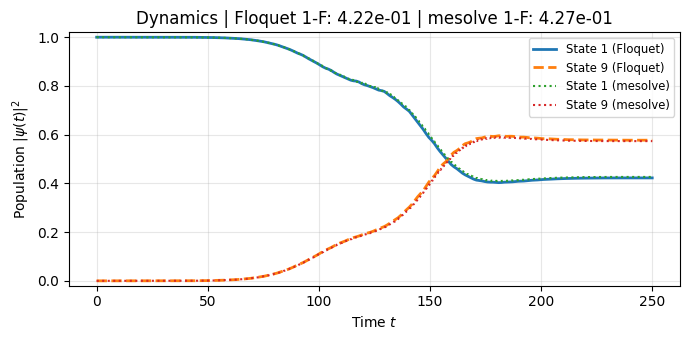

In [ ]:
import matplotlib.pyplot as plt

# 1. Feines Zeitraster für mesolve definieren & Puls auswerten
N_t_mesolve = 1001
tlist_mesolve = np.linspace(0, tg, N_t_mesolve)

t_sym = sy.Symbol("t", real=True)
p_syms = [sy.Symbol(k, real=True) for k in param_ranges.keys()]
A_expr, wd_expr = fitted_pulse_with_offset(t_sym, p_syms)

A_func = sy.lambdify([t_sym] + p_syms, A_expr, modules=['numpy'])
wd_func = sy.lambdify([t_sym] + p_syms, wd_expr, modules=['numpy'])

best_p_vals = tuple(best_p[k] for k in param_ranges.keys())
A_t = A_func(tlist_mesolve, *best_p_vals)
wd_t = wd_func(tlist_mesolve, *best_p_vals)

def qutip_signal(t, args=None):
    idx = min(int(t / tg * (N_t_mesolve - 1)), N_t_mesolve - 1)
    return float(np.real(A_t[idx]) * np.cos(wd_t[idx] * t) + np.imag(A_t[idx]) * np.sin(wd_t[idx] * t))

# 2. Mesolve-Dynamik auf feinem Raster berechnen
H = [s.H0, [s.V1, qutip_signal]]
res_keys = list(dict(s.resonances).keys()) if isinstance(s.resonances, list) else list(s.resonances.keys())
ind_a, ind_b = res_keys.index(s.state_a), res_keys.index(s.state_b)

amp_a = resonant_subspace_column_evolution(H, tlist_mesolve, ind_a, debug=False, s=s)
amp_b = resonant_subspace_column_evolution(H, tlist_mesolve, ind_b, debug=False, s=s)

p_ab, p_ba = np.abs(amp_a[ind_b, -1])**2, np.abs(amp_b[ind_a, -1])**2
infid_mesolve = 1.0 - 0.5 * (p_ab + p_ba)

# 3. Plot auf separaten Zeitrastern
plt.figure(figsize=(7, 3.5))
plt.plot(tlist, np.abs(best_psi_t[s.state_a, :])**2, label=f'State {s.state_a} (Floquet)', lw=2)
plt.plot(tlist, np.abs(best_psi_t[s.state_b, :])**2, label=f'State {s.state_b} (Floquet)', lw=2, ls='--')
plt.plot(tlist_mesolve, np.abs(amp_a[ind_a, :])**2, label=f'State {s.state_a} (mesolve)', lw=1.5, ls=':')
plt.plot(tlist_mesolve, np.abs(amp_a[ind_b, :])**2, label=f'State {s.state_b} (mesolve)', lw=1.5, ls=':')

plt.xlabel(r'Time $t$')
plt.ylabel(r'Population $|\psi(t)|^2$')
plt.title(f'Dynamics | Floquet 1-F: {best_infid:.2e} | mesolve 1-F: {infid_mesolve:.2e}')
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fontsize='small')
plt.tight_layout()
plt.show()